# **WElCOM to this step** 

# *Preprocessing Data and EDA*

In [1]:
import pandas as pd
import json
import os
import matplotlib.pyplot as plt
from PIL import Image

DATASET_PATH = "/kaggle/input/datasets/abedgaha/datasetextracttextfromimgfordonut/Donut_Dataset/train" # تأكد من تغيير اسم الداتا سيت
JSONL_FILE = os.path.join(DATASET_PATH, "metadata.jsonl")

# 1. قراءة ملف JSONL وتحويله لـ DataFrame
data = []
with open(JSONL_FILE, 'r', encoding='utf-8') as f:
    for line in f:
        item = json.loads(line)
        # فك تشفير ground_truth لأنه مخزن كـ string داخل الـ JSONL
        gt = json.loads(item['ground_truth'])['gt_parse']
        
        # إضافة اسم الصورة والبيانات الغذائية للجدول
        data.append({
            "image": item['file_name'],
            "sodium_mg": gt.get("sodium", "N/A"),
            "saturated_fat_g": gt.get("saturated_fat", "N/A"),
            "cholesterol_mg": gt.get("cholesterol", "N/A")
        })

In [2]:

df = pd.DataFrame(data)

print("📊 لمحة عن جدول البيانات:")
display(df.head())

print("\n📝 إحصائيات سريعة:")
print(f"- إجمالي عدد الصور: {len(df)}")
print(f"- عدد القيم المفقودة للصوديوم: {sum(df['sodium_mg'] == 'N/A')}")
print(f"- عدد القيم الفاقدة للدهون: {sum(df['saturated_fat_g'] == 'N/A')}")
print(f"- عدد القيم المفقودة للكوليسترول: {sum(df['cholesterol_mg'] == 'N/A')}")

📊 لمحة عن جدول البيانات:


,image,sodium_mg,saturated_fat_g,cholesterol_mg
0,img_257.png,0.0,0.0,0.0
1,img_328.png,90.0,0.3,0.0
2,img_497.png,130.0,0.0,0.0
3,img_39.png,180.0,0.0,0.0
4,img_527.png,320.0,5.0,30.0



📝 إحصائيات سريعة:
- إجمالي عدد الصور: 214
- عدد القيم المفقودة للصوديوم: 18
- عدد القيم الفاقدة للدهون: 8
- عدد القيم المفقودة للكوليسترول: 80


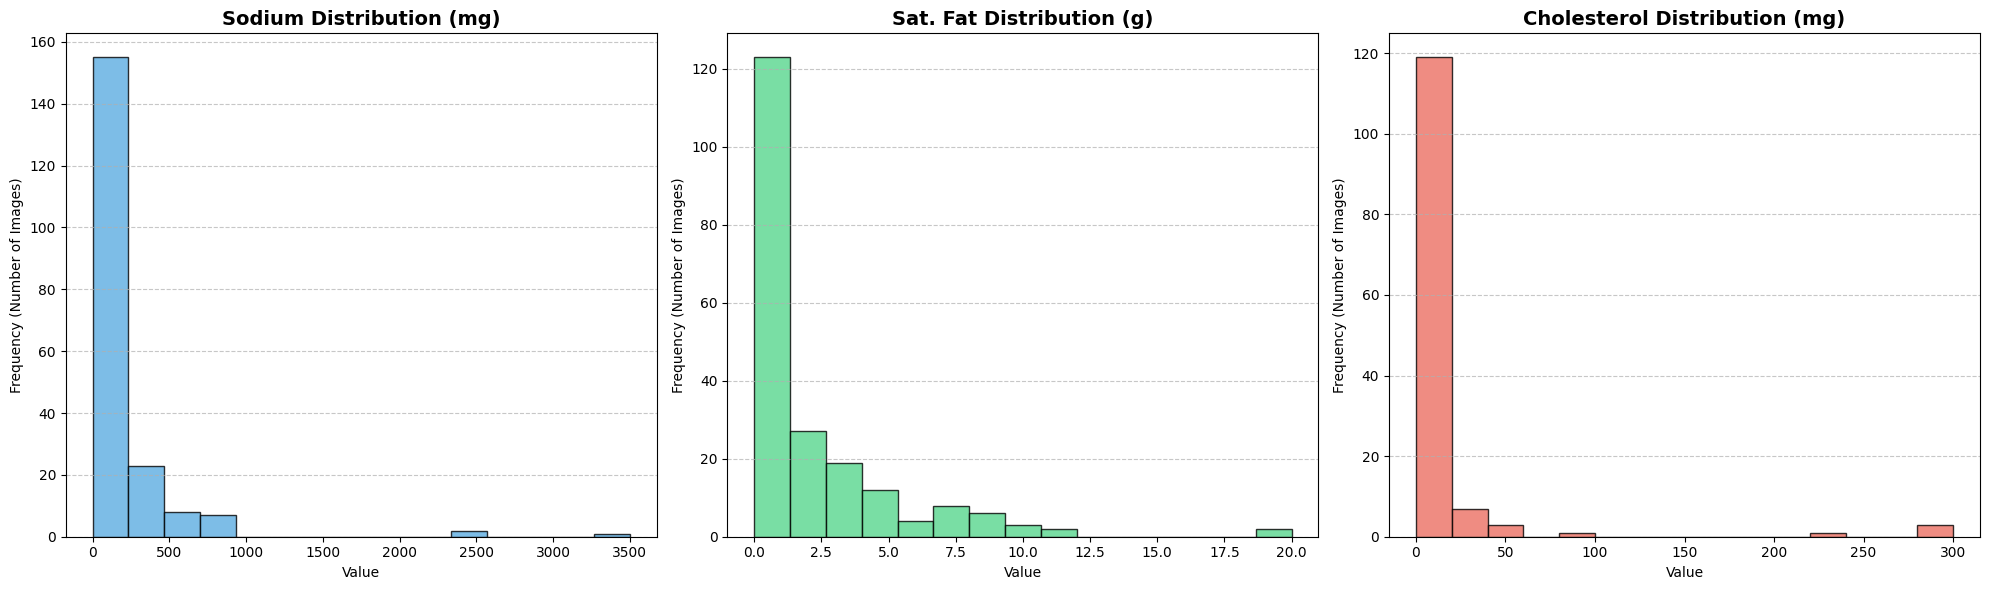

📋 الإحصائيات التحليلية للأعمدة الثلاثة:


,sodium_mg,saturated_fat_g,cholesterol_mg
count,196.000000,206.000000,134.000000
mean,189.855663,2.042718,12.970149
std,380.284149,3.120760,48.876235
min,0.000000,0.000000,0.000000
25%,15.000000,0.000000,0.000000
50%,80.000000,0.950000,0.000000
75%,205.000000,3.000000,5.000000
max,3500.000000,20.000000,300.000000


In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. تحضير البيانات: تحويل القيم إلى أرقام ومعالجة القيم المفقودة
# نقوم بنسخ الجدول الأصلي لتجنب التأثير عليه
df_stats = df.copy()

cols = ['sodium_mg', 'saturated_fat_g', 'cholesterol_mg']

for col in cols:
    # تحويل "N/A" إلى قيمة فارغة حقيقية ثم تحويل العمود لرقمي
    df_stats[col] = pd.to_numeric(df_stats[col].replace("N/A", np.nan))

# 2. إعداد لوحة الرسم (3 رسوم بيانية في صف واحد)
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
colors = ['#5dade2', '#58d68d', '#ec7063'] # أزرق، أخضر، أحمر
titles = ['Sodium Distribution (mg)', 'Sat. Fat Distribution (g)', 'Cholesterol Distribution (mg)']

# 3. حلقة تكرارية لرسم كل عمود
for i, col in enumerate(cols):
    # إزالة القيم المفقودة فقط للعمود الحالي أثناء الرسم
    data_to_plot = df_stats[col].dropna()
    
    axes[i].hist(data_to_plot, bins=15, color=colors[i], edgecolor='black', alpha=0.8)
    axes[i].set_title(titles[i], fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency (Number of Images)')
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

# تحسين المسافات بين الرسوم
plt.tight_layout()
plt.show()

# 4. عرض إحصائيات وصفية سريعة أسفل الرسم
print("📋 الإحصائيات التحليلية للأعمدة الثلاثة:")
display(df_stats[cols].describe())

In [4]:
import pandas as pd
import numpy as np

def handle_and_replace_outliers(df, columns):
    # نقوم بإنشاء نسخة للعمل عليها للحفاظ على البيانات الأصلية إذا أردنا
    df_cleaned = df.copy()
    
    for col in columns:
        # 1. تحويل العمود لرقمي مؤقتاً لحساب الحدود (معالجة N/A)
        numeric_data = pd.to_numeric(df_cleaned[col].replace("N/A", np.nan))
        
        # 2. حساب الربيع الأول (25%) والثالث (75%)
        Q1 = numeric_data.quantile(0.25)
        Q3 = numeric_data.quantile(0.75)
        IQR = Q3 - Q1
        
        # 3. تحديد الحدود بناءً على معامل 2 الذي اخترته
        lower_bound = Q1 - 2 * IQR
        upper_bound = Q3 + 2 * IQR
        
        # 4. عملية الاستبدال (Clipping)
        # القيم أكبر من الحد الأعلى تصبح upper_bound
        # القيم أصغر من الحد الأدنى تصبح lower_bound
        df_cleaned[col] = numeric_data.clip(lower=lower_bound, upper=upper_bound)
        
        # 5. طباعة تقرير العمليات للتأكد
        num_outliers = ((numeric_data > upper_bound) | (numeric_data < lower_bound)).sum()
        print(f"✅ العمود: {col}")
        print(f"   - تم تحديد الحدود عند: [{lower_bound:.2f} , {upper_bound:.2f}]")
        print(f"   - عدد القيم التي تم تعديلها: {num_outliers}")
        print("-" * 40)
        
    return df_cleaned

# --- التشغيل ---
cols = ['sodium_mg', 'saturated_fat_g', 'cholesterol_mg']
# استدعاء التابع وحفظ النتائج في جدول جديد
df_final = handle_and_replace_outliers(df, cols)

# عرض إحصائيات للتأكد من أن القيم القصوى (Max) لم تعد تتجاوز الحدود
print("\n📊 القيم  بعد التعديل:")
display(df_final[cols].max())
display(df_final[cols].min())

✅ العمود: sodium_mg
   - تم تحديد الحدود عند: [-365.00 , 585.00]
   - عدد القيم التي تم تعديلها: 11
----------------------------------------
✅ العمود: saturated_fat_g
   - تم تحديد الحدود عند: [-6.00 , 9.00]
   - عدد القيم التي تم تعديلها: 8
----------------------------------------
✅ العمود: cholesterol_mg
   - تم تحديد الحدود عند: [-10.00 , 15.00]
   - عدد القيم التي تم تعديلها: 15
----------------------------------------

📊 القيم  بعد التعديل:


sodium_mg          585.0
saturated_fat_g      9.0
cholesterol_mg      15.0
dtype: float64

sodium_mg          0.0
saturated_fat_g    0.0
cholesterol_mg     0.0
dtype: float64

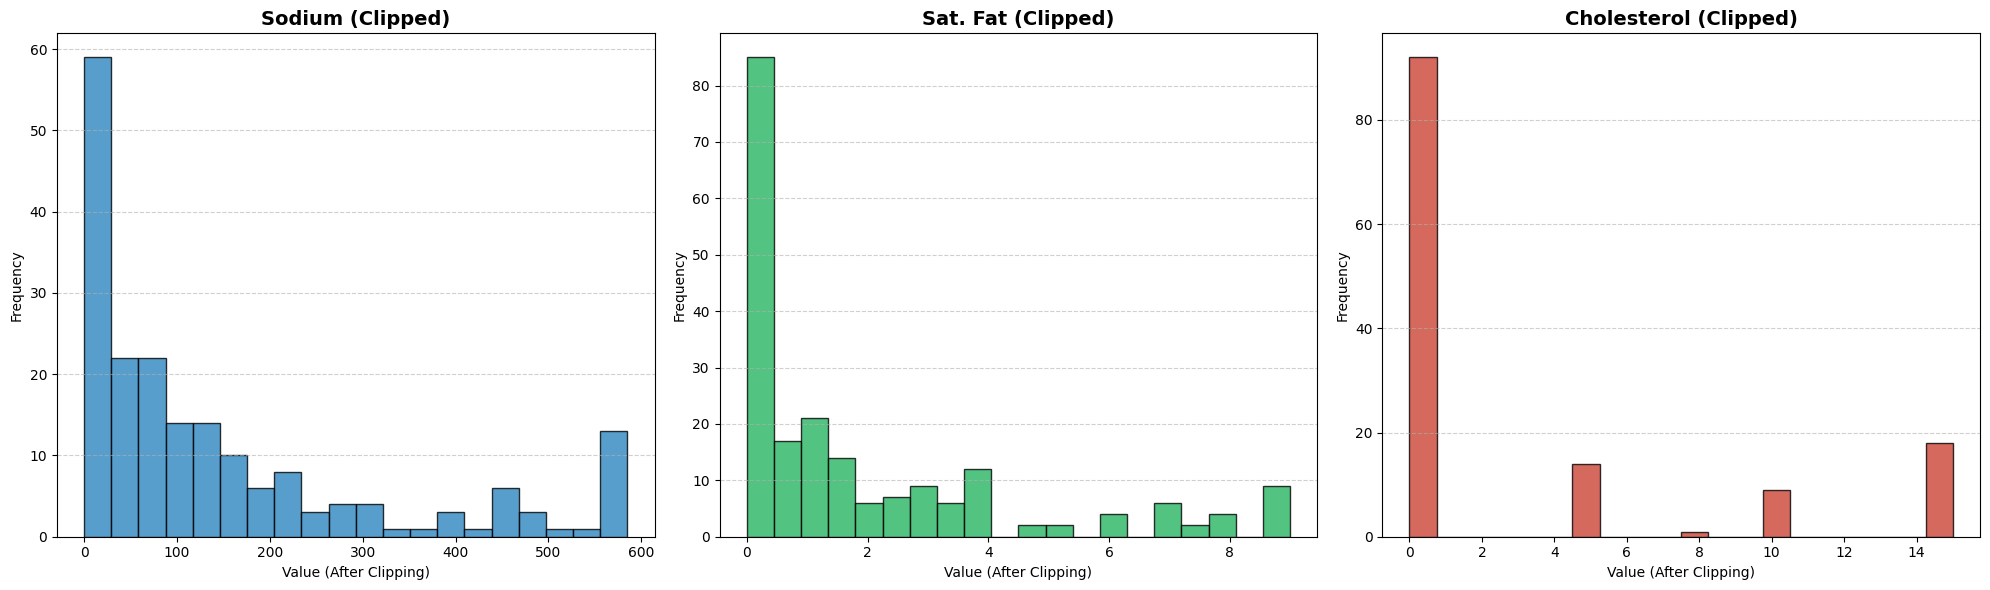

📊 الإحصائيات الوصفية بعد معالجة القيم الشاذة (Clipping):


,sodium_mg,saturated_fat_g,cholesterol_mg
count,196.000000,206.000000,134.000000
mean,147.789337,1.902913,3.268657
std,172.954487,2.555891,5.437497
min,0.000000,0.000000,0.000000
25%,15.000000,0.000000,0.000000
50%,80.000000,0.950000,0.000000
75%,205.000000,3.000000,5.000000
max,585.000000,9.000000,15.000000


In [5]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# التأكد من استخدام البيانات النظيفة (df_final)
cols = ['sodium_mg', 'saturated_fat_g', 'cholesterol_mg']

# 1. إعداد لوحة الرسم
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
colors = ['#2e86c1', '#28b463', '#cb4335'] # ألوان أغمق قليلاً للتميز عن الرسم السابق
titles = ['Sodium (Clipped)', 'Sat. Fat (Clipped)', 'Cholesterol (Clipped)']

# 2. حلقة تكرارية للرسم
for i, col in enumerate(cols):
    data_to_plot = df_final[col].dropna()
    
    # سنزيد عدد الـ bins لترى كيف تجمعت الشواذ عند الحواف
    axes[i].hist(data_to_plot, bins=20, color=colors[i], edgecolor='black', alpha=0.8)
    axes[i].set_title(titles[i], fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Value (After Clipping)')
    axes[i].set_ylabel('Frequency')
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# 3. عرض الإحصائيات الجديدة للمقارنة
print("📊 الإحصائيات الوصفية بعد معالجة القيم الشاذة (Clipping):")
display(df_final[cols].describe())

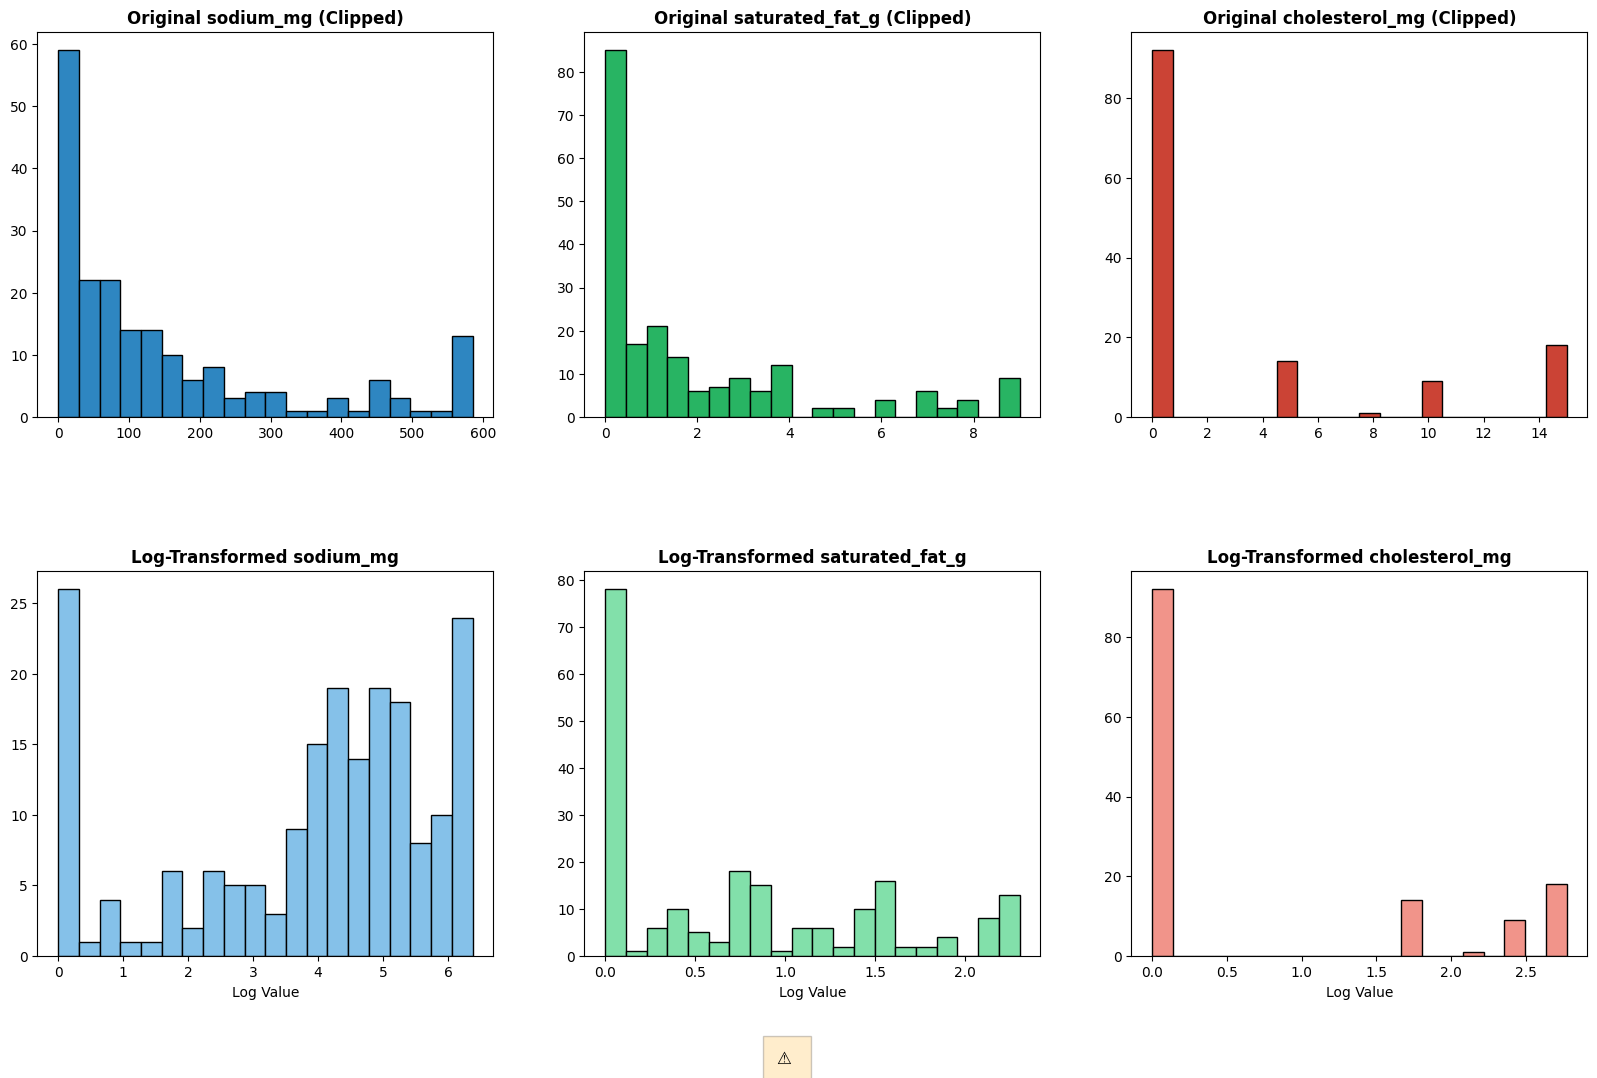

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. حساب القيم اللوغاريتميّة (نستخدم log1p للتعامل مع القيم الصفرية: log(1+x))
df_log = df_final.copy()
for col in cols:
    df_log[f'{col}_log'] = np.log1p(df_log[col])

# 2. إعداد الرسم البياني للمقارنة
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
plt.subplots_adjust(hspace=0.4)

colors_raw = ['#2e86c1', '#28b463', '#cb4335']
colors_log = ['#85c1e9', '#82e0aa', '#f1948a']

for i, col in enumerate(cols):
    # رسم التوزيع الأصلي (بعد التقليم)
    axes[0, i].hist(df_log[col].dropna(), bins=20, color=colors_raw[i], edgecolor='black')
    axes[0, i].set_title(f'Original {col} (Clipped)', fontweight='bold')
    
    # رسم التوزيع اللوغاريتمي
    axes[1, i].hist(df_log[f'{col}_log'].dropna(), bins=20, color=colors_log[i], edgecolor='black')
    axes[1, i].set_title(f'Log-Transformed {col}', fontweight='bold')
    axes[1, i].set_xlabel('Log Value')

# 3. إضافة شرح السلبيات كتعليق نصي أسفل الرسم
explanation = (
    "⚠️ "
)
plt.figtext(0.5, 0.02, explanation, wrap=True, horizontalalignment='center', 
            fontsize=12, bbox={'facecolor':'orange', 'alpha':0.2, 'pad':10})

plt.show()

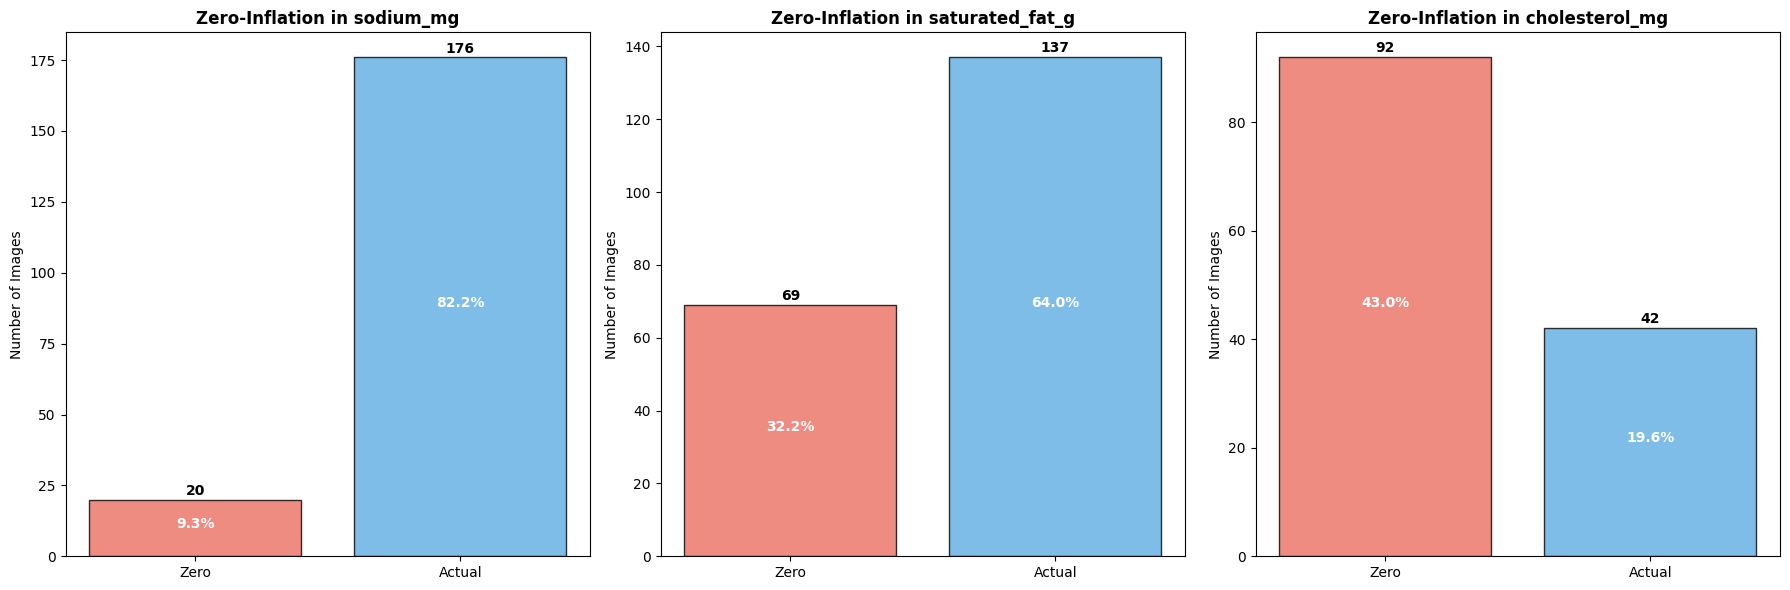

In [7]:
import matplotlib.pyplot as plt

def plot_zeros_for_all_metrics(df, columns):
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    colors = ['#ec7063', '#5dade2'] # أحمر للأصفار، أزرق للقيم الفعلية
    
    for i, col in enumerate(columns):
        # حساب التكرارات
        zero_count = (df[col] == 0).sum()
        others_count = (df[col] > 0).sum()
        
        labels = ['Zero', 'Actual']
        counts = [zero_count, others_count]
        
        # رسم البار
        bars = axes[i].bar(labels, counts, color=colors, edgecolor='black', alpha=0.8)
        axes[i].set_title(f'Zero-Inflation in {col}', fontsize=12, fontweight='bold')
        axes[i].set_ylabel('Number of Images')
        
        # إضافة الأرقام فوق الأعمدة
        for bar in bars:
            height = bar.get_height()
            axes[i].text(bar.get_x() + bar.get_width()/2., height + 0.5,
                        f'{int(height)}', ha='center', va='bottom', fontweight='bold')
            
            # إضافة النسبة المئوية للتوضيح البحثي
            percentage = (height / len(df)) * 100
            axes[i].text(bar.get_x() + bar.get_width()/2., height / 2,
                        f'{percentage:.1f}%', ha='center', color='white', fontweight='bold')

    plt.tight_layout()
    plt.show()

# --- التشغيل ---
cols = ['sodium_mg', 'saturated_fat_g', 'cholesterol_mg']
plot_zeros_for_all_metrics(df_final, cols)

In [8]:
def check_priority_ranges_detailed(df, columns):
    print("📋 Data Distribution Analysis (Low vs Mid vs High):")
    print("=" * 60)
    
    for col in columns:
        # Dropping missing values for accurate statistical calculation
        data = df[col].dropna()
        
        # Calculating Quantiles (Thresholds)
        q33 = data.quantile(0.33)
        q66 = data.quantile(0.66)
        
        # Categorizing the data
        low_count = data[data <= q33].shape[0]
        mid_count = data[(data > q33) & (data <= q66)].shape[0]
        high_count = data[data > q66].shape[0]
        
        total = data.shape[0]
        
        print(f"📊 Feature: {col}")
        print(f"   - Low Range      (<= {q33:.1f}): {low_count:4d} samples | Percentage: {(low_count/total)*100:5.1f}%")
        print(f"   - Medium Range   (> {q33:.1f} and <= {q66:.1f}): {mid_count:4d} samples | Percentage: {(mid_count/total)*100:5.1f}%")
        print(f"   - High Range     (> {q66:.1f}): {high_count:4d} samples | Percentage: {(high_count/total)*100:5.1f}%")
        print("-" * 60)

# --- Execution ---
cols = ['sodium_mg', 'saturated_fat_g', 'cholesterol_mg']
check_priority_ranges_detailed(df_final, cols)

📋 Data Distribution Analysis (Low vs Mid vs High):
📊 Feature: sodium_mg
   - Low Range      (<= 36.1):   65 samples | Percentage:  33.2%
   - Medium Range   (> 36.1 and <= 140.0):   66 samples | Percentage:  33.7%
   - High Range     (> 140.0):   65 samples | Percentage:  33.2%
------------------------------------------------------------
📊 Feature: saturated_fat_g
   - Low Range      (<= 0.0):   69 samples | Percentage:  33.5%
   - Medium Range   (> 0.0 and <= 1.6):   67 samples | Percentage:  32.5%
   - High Range     (> 1.6):   70 samples | Percentage:  34.0%
------------------------------------------------------------
📊 Feature: cholesterol_mg
   - Low Range      (<= 0.0):   92 samples | Percentage:  68.7%
   - Medium Range   (> 0.0 and <= 0.0):    0 samples | Percentage:   0.0%
   - High Range     (> 0.0):   42 samples | Percentage:  31.3%
------------------------------------------------------------


In [9]:
import pandas as pd

def apply_cholesterol_oversampling(df, multiplier=3):
    """
    تكرار العينات التي تحتوي على كوليسترول أكبر من الصفر.
    multiplier=3 تعني إضافة 3 نسخ إضافية (الإجمالي 4 نسخ).
    """
    # 1. عزل العينات التي تحتوي على قيمة كوليسترول حقيقية (أكبر من صفر)
    # ملاحظة: استبعاد القيم المفقودة (NaN) تلقائياً لأن (NaN > 0) تعطي False
    chol_positive_df = df[df['cholesterol_mg'] > 0].copy()
    
    print(f"📊 Cholesterol Analysis:")
    print(f"   - Number of unique non-zero samples: {len(chol_positive_df)}")
    
    # 2. تكرار هذه العينات بمقدار الماعمل المطلوب
    # concat تقوم بنسخ الأسطر ووضعها تحت بعضها
    boosted_samples = pd.concat([chol_positive_df] * multiplier, ignore_index=True)
    
    # 3. دمج النسخ الجديدة مع الجدول الأصلي (df_final)
    df_balanced = pd.concat([df, boosted_samples], ignore_index=True)
    
    # 4. خلط البيانات (Shuffle)
    # هذا الخطوة ضرورية جداً حتى لا يتعلم النموذج العينات المتكررة وراء بعضها (Sequential Bias)
    df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)
    
    print(f"✅ Oversampling Complete:")
    print(f"   - Total samples after boost: {len(df_balanced)}")
    print(f"   - Total non-zero Cholesterol samples now: {len(df_balanced[df_balanced['cholesterol_mg'] > 0])}")
    
    return df_balanced

# --- تشغيل الكود ---
# نستخدم df_final الذي يحتوي على البيانات المنظفة والمعدلة
df_ready_for_train = apply_cholesterol_oversampling(df_final, multiplier=3)

# مراجعة سريعة لأول 5 أسطر للتأكد من التوزيع
display(df_ready_for_train.head())

📊 Cholesterol Analysis:
   - Number of unique non-zero samples: 42
✅ Oversampling Complete:
   - Total samples after boost: 340
   - Total non-zero Cholesterol samples now: 168


,image,sodium_mg,saturated_fat_g,cholesterol_mg
0,img_26.png,240.0,1.0,5.0
1,img_82.png,0.0,0.0,15.0
2,img_124.png,135.0,2.0,0.0
3,img_4.png,0.0,0.0,0.0
4,img_76.png,5.0,0.1,NaN


In [10]:
df_ready_for_train.shape

(340, 4)

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


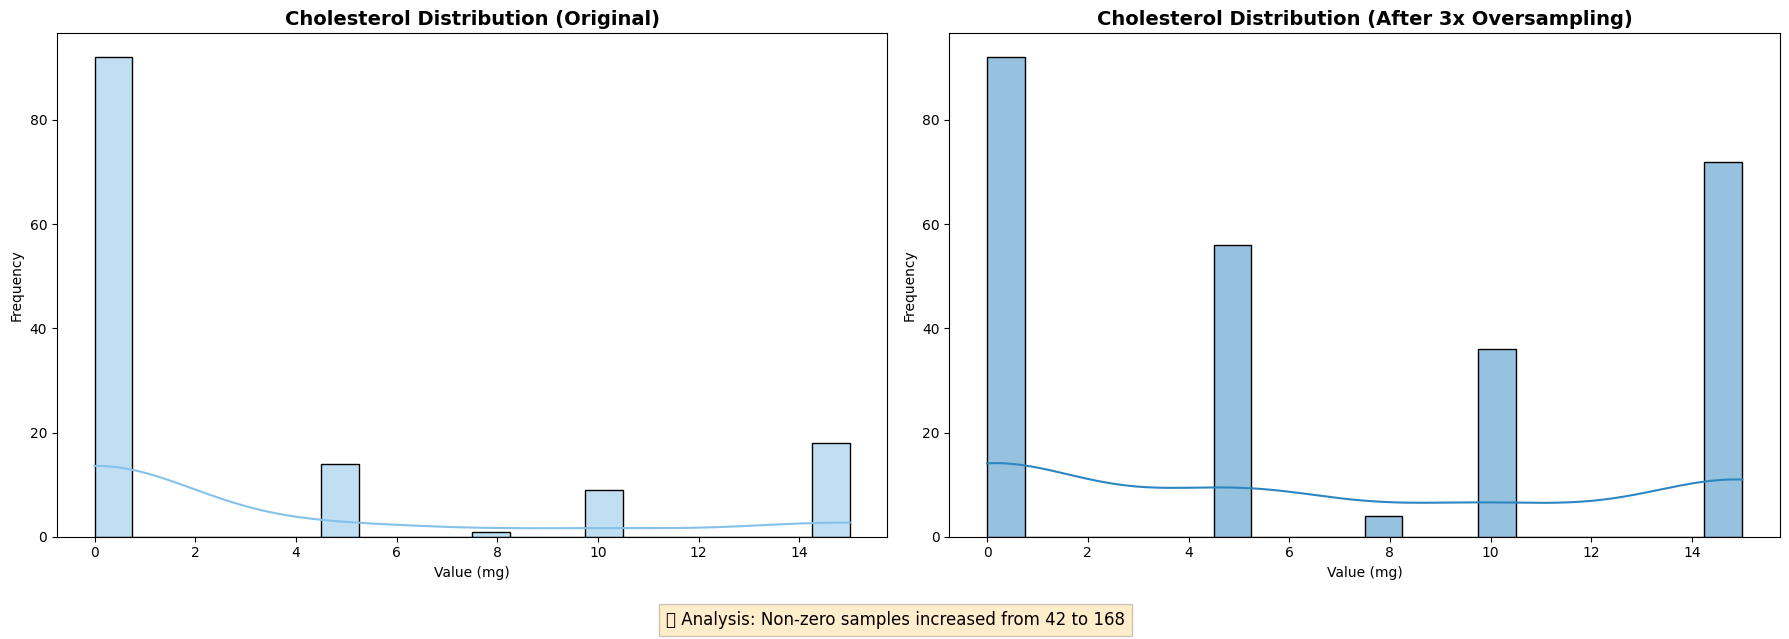

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_cholesterol_after_oversampling(df_before, df_after):
    # إعداد لوحة الرسم (رسمين متجاورين للمقارنة)
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    
    # 1. التوزيع قبل الـ Oversampling
    sns.histplot(df_before['cholesterol_mg'].dropna(), bins=20, ax=axes[0], color='#85c1e9', kde=True)
    axes[0].set_title('Cholesterol Distribution (Original)', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Value (mg)')
    axes[0].set_ylabel('Frequency')
    
    # 2. التوزيع بعد الـ Oversampling
    sns.histplot(df_after['cholesterol_mg'].dropna(), bins=20, ax=axes[1], color='#2e86c1', kde=True)
    axes[1].set_title('Cholesterol Distribution (After 3x Oversampling)', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Value (mg)')
    axes[1].set_ylabel('Frequency')

    # إضافة إحصائيات نصية للتوضيح
    original_non_zero = (df_before['cholesterol_mg'] > 0).sum()
    after_non_zero = (df_after['cholesterol_mg'] > 0).sum()
    
    plt.figtext(0.5, -0.05, 
                f"📊 Analysis: Non-zero samples increased from {original_non_zero} to {after_non_zero}", 
                ha="center", fontsize=12, bbox={"facecolor":"orange", "alpha":0.2, "pad":5})

    plt.tight_layout()
    plt.show()

# --- التشغيل ---
# df_final: البيانات الأصلية المنظفة
# df_ready_for_train: البيانات بعد الـ Oversampling
plot_cholesterol_after_oversampling(df_final, df_ready_for_train)

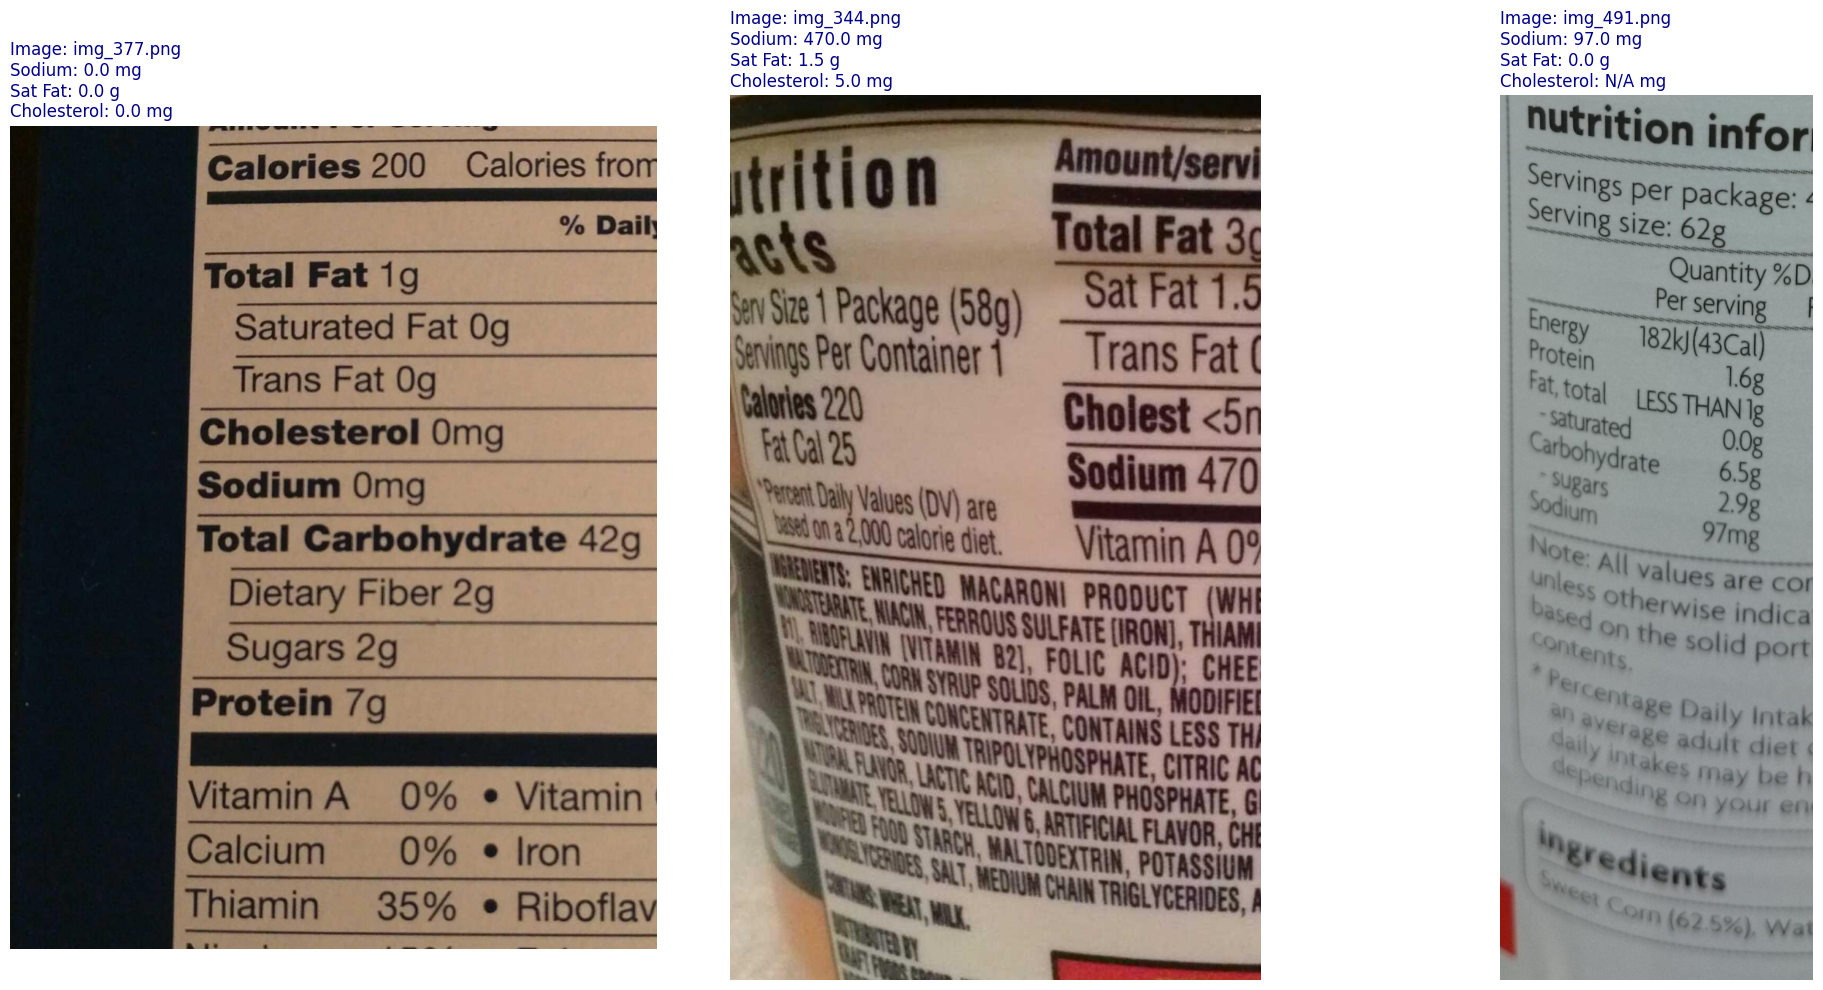

In [12]:
def plot_samples(df, path, num_samples=3):
    # اختيار عينات عشوائية
    samples = df.sample(num_samples)
    
    plt.figure(figsize=(20, 10))
    
    for i, (idx, row) in enumerate(samples.iterrows()):
        img_path = os.path.join(path, row['image'])
        img = Image.open(img_path)
        
        plt.subplot(1, num_samples, i + 1)
        plt.imshow(img)
        
        # بناء النص الذي سيظهر فوق الصورة
        info_text = (f"Image: {row['image']}\n"
                     f"Sodium: {row['sodium_mg']} mg\n"
                     f"Sat Fat: {row['saturated_fat_g']} g\n"
                     f"Cholesterol: {row['cholesterol_mg']} mg")
        
        plt.title(info_text, fontsize=12, color='darkblue', loc='left')
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

# تشغيل العرض
plot_samples(df, DATASET_PATH)

# **Zero-shot Model**

In [13]:
!pip install -q transformers sentencepiece

In [14]:
import os
import json
import torch
import cv2
import numpy as np
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from transformers import DonutProcessor, VisionEncoderDecoderModel
from tqdm.auto import tqdm
import albumentations as A
from albumentations.pytorch import ToTensorV2

# --- 1. إعدادات المسارات والمعايير ---
JSONL_FILE = "/kaggle/input/datasets/abedgaha/datasetextracttextfromimgfordonut/Donut_Dataset/train/metadata.jsonl"
TRAIN_DIR = "/kaggle/input/datasets/abedgaha/datasetextracttextfromimgfordonut/Donut_Dataset/train"
device = "cuda" if torch.cuda.is_available() else "cpu"

In [15]:
# --- 2. قراءة وتحضير البيانات من ملف JSONL ---
data = []
def clean_val(v):
    if v == "N/A" or v is None: return 0
    try: return float(''.join(filter(str.isdigit, str(v))))
    except: return 0

with open(JSONL_FILE, 'r', encoding='utf-8') as f:
    for line in f:
        item = json.loads(line)
        full_gt_string = item['ground_truth'] 
        gt_parsed = json.loads(full_gt_string)['gt_parse']
        
        data.append({
            "image": item['file_name'],
            "ground_truth": full_gt_string, # العمود المخصص لتدريب النموذج
            "sodium_mg": clean_val(gt_parsed.get("sodium")),
            "saturated_fat_g": clean_val(gt_parsed.get("saturated_fat")),
            "cholesterol_mg": clean_val(gt_parsed.get("cholesterol"))
        })

df_ready_for_train = pd.DataFrame(data)
print(f"✅ Data loaded: {len(df_ready_for_train)} samples.")

✅ Data loaded: 214 samples.


In [16]:
# --- 3. إعداد التعزيز (Augmentation) ---
base_transform = A.Compose([
    A.Rotate(limit=5, p=0.5),
    A.RandomBrightnessContrast(p=0.5),
    A.GaussNoise(p=0.3),
    A.Resize(960, 960),
    A.Normalize(),
    ToTensorV2()
])

intensive_transform = A.Compose([
    A.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, p=0.8),
    A.Sharpen(p=0.5),
    A.Resize(960, 960),
    A.Normalize(),
    ToTensorV2()
])

In [17]:
# --- 4. فئة الـ Dataset المخصصة ---
class DonutNutritionDataset(Dataset):
    def __init__(self, df, root_dir, processor):
        self.df = df
        self.root_dir = root_dir
        self.processor = processor

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.root_dir, row['image'])
        image = cv2.imread(img_path)
        if image is None: image = cv2.imread(row['image'])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Targeted Augmentation بناءً على القيم الرقمية
        if row['cholesterol_mg'] > 50 or row['saturated_fat_g'] > 10:
            image = intensive_transform(image=image)['image']
        else:
            image = base_transform(image=image)['image']

        labels = self.processor.tokenizer(
            row['ground_truth'], 
            add_special_tokens=True, 
            max_length=512, 
            padding="max_length", 
            truncation=True, 
            return_tensors="pt"
        ).input_ids.squeeze(0)

        return {"pixel_values": image, "labels": labels}

In [18]:
# --- 5. تحميل النموذج وإعداد الـ DataLoader ---
processor = DonutProcessor.from_pretrained("naver-clova-ix/donut-base")
model = VisionEncoderDecoderModel.from_pretrained("naver-clova-ix/donut-base").to(device)

preprocessor_config.json:   0%|          | 0.00/362 [00:00<?, ?B/s]

The image processor of type `DonutImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/518 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/355 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/809M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/484 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/809M [00:00<?, ?B/s]

The tied weights mapping and config for this model specifies to tie decoder.model.decoder.embed_tokens.weight to decoder.lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


In [19]:
# Sampler لضمان توزيع البيانات داخل الـ Patch
weights = df_ready_for_train.apply(lambda x: 4.0 if x['cholesterol_mg'] > 0 else 1.0, axis=1).values
sampler = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)
train_dataloader = DataLoader(DonutNutritionDataset(df_ready_for_train, TRAIN_DIR, processor), batch_size=2, sampler=sampler)

# --- 6. تجميد الطبقات (Swin Strategy) ---
for param in model.encoder.parameters():
    param.requires_grad = False
try:
    for param in model.encoder.encoder.layers[-1].parameters(): # فتح آخر Stage
        param.requires_grad = True
except AttributeError:
    for param in list(model.encoder.parameters())[-20:]:
        param.requires_grad = True

for param in model.decoder.parameters():
    param.requires_grad = True

In [20]:
# --- 7. حلقة التدريب مع Early Stopping ---
# --- تحديث الإعدادات قبل التدريب ---
model.config.pad_token_id = processor.tokenizer.pad_token_id
model.config.decoder_start_token_id = processor.tokenizer.bos_token_id
optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=2e-5)
num_epochs = 15
patience = 3
best_loss = float('inf')
epochs_without_improvement = 0

print("🚀 Starting Training...")
for epoch in range(num_epochs):
    model.train()
    total_train_loss = 0
    pbar = tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{num_epochs}")
    
    for batch in pbar:
        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(pixel_values=pixel_values, labels=labels)
        loss = outputs.loss
        
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        
        total_train_loss += loss.item()
        pbar.set_postfix(loss=loss.item())

    avg_train_loss = total_train_loss / len(train_dataloader)
    print(f"📢 Epoch {epoch+1} Avg Loss: {avg_train_loss:.4f}")

    if avg_train_loss < best_loss:
        best_loss = avg_train_loss
        epochs_without_improvement = 0
        model.save_pretrained("./donut_best_model_agha")
        processor.save_pretrained("./donut_best_model_agha")
        print(f"⭐ Best model saved!")
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= patience:
            print("🛑 Early Stopping triggered.")
            break

🚀 Starting Training...


Epoch 1/15:   0%|          | 0/107 [00:00<?, ?it/s]

📢 Epoch 1 Avg Loss: 4.7422


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

⭐ Best model saved!


...

⭐ Best model saved!


Epoch 15/15:   0%|          | 0/107 [00:00<?, ?it/s]

📢 Epoch 15 Avg Loss: 0.0074


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

⭐ Best model saved!


In [21]:
import torch
from transformers import DonutProcessor, VisionEncoderDecoderModel
import re
from PIL import Image

# إعداد الجهاز والمسارات
device = "cuda" if torch.cuda.is_available() else "cpu"
model_path = "./donut_best_model_agha" # المسار الذي حفظت فيه النموذج

# تحميل المعالج والنموذج المدرب
processor = DonutProcessor.from_pretrained(model_path)
model = VisionEncoderDecoderModel.from_pretrained(model_path).to(device)
model.eval() # وضع النموذج في نمط التقييم

Loading weights:   0%|          | 0/484 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie decoder.model.decoder.embed_tokens.weight to decoder.lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


VisionEncoderDecoderModel(
  (encoder): DonutSwinModel(
    (embeddings): DonutSwinEmbeddings(
      (patch_embeddings): DonutSwinPatchEmbeddings(
        (projection): Conv2d(3, 128, kernel_size=(4, 4), stride=(4, 4))
      )
      (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): DonutSwinEncoder(
      (layers): ModuleList(
        (0): DonutSwinStage(
          (blocks): ModuleList(
            (0): DonutSwinLayer(
              (layernorm_before): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
              (attention): DonutSwinAttention(
                (self): DonutSwinSelfAttention(
                  (query): Linear(in_features=128, out_features=128, bias=True)
                  (key): Linear(in_features=128, out_features=128, bias=True)
                  (value): Linear(in_features=128, out_features=128, bias=True)
                  (dropout): Dropout(p=0.0, inplace=False)
                )

In [22]:
def extract_nutrition_info(image_path):
    # 1. تحميل الصورة ومعالجتها بأسلوب Donut
    image = Image.open(image_path).convert("RGB")
    pixel_values = processor(image, return_tensors="pt").pixel_values.to(device)

    # 2. إعداد الـ Token الأول لبدء التوليد (Task Start Token)
    task_prompt = "<s>" # الرمز الافتراضي لبداية المهمة في Donut
    decoder_input_ids = processor.tokenizer(task_prompt, add_special_tokens=False, return_tensors="pt").input_ids.to(device)

    # 3. توليد المخرجات (Generation)
    with torch.no_grad():
        outputs = model.generate(
            pixel_values,
            decoder_input_ids=decoder_input_ids,
            max_length=model.decoder.config.max_position_embeddings,
            early_stopping=True,
            pad_token_id=processor.tokenizer.pad_token_id,
            eos_token_id=processor.tokenizer.eos_token_id,
            use_cache=True,
            num_beams=1,
            bad_words_ids=[[processor.tokenizer.unk_token_id]],
            return_dict_in_generate=True,
        )

    # 4. فك تشفير النص الناتج وتحويله لـ JSON
    sequence = processor.batch_decode(outputs.sequences)[0]
    sequence = sequence.replace(processor.tokenizer.eos_token, "").replace(processor.tokenizer.pad_token, "")
    sequence = re.sub(r"<.*?>", "", sequence, count=1).strip() # إزالة أول تاكن للمهمة
    
    # تحويل النص المستخرج إلى هيكل JSON منظم
    prediction = processor.token2json(sequence)
    return prediction

In [23]:
# تجربة على صورة جديدة
test_image = "/kaggle/input/datasets/abedgaha/datasetextracttextfromimgfordonut/Donut_Dataset/validation/img_214.png"
result = extract_nutrition_info(test_image)

# عرض النتيجة
print("--- extracted JSON Result ---")
print(result)

# حفظ النتيجة في ملف JSON خارجي
import json
with open('nutrition_output.json', 'w', encoding='utf-8') as f:
    json.dump(result, f, ensure_ascii=False, indent=4)

print("✅ Saved to nutrition_output.json")

The following generation flags are not valid and may be ignored: ['early_stopping']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


--- extracted JSON Result ---
{'text_sequence': '<s> {"gt_parse": {"saturated_fat": "0.0", "sodium": "0.0"}}'}
✅ Saved to nutrition_output.json
